# Load Dataset

In [1]:
from dataset import Dataset

dataset = Dataset(path="./data/state/ILINet.csv")
train_loader, val_loader, test_loader= dataset.get_train_val_test_loader(
    history=10,
    future=4,
    batch_size=64
)

HISTORY = 10
FUTURE  = 4
TEST_SIZE = 0.2

Train samples: 15295
Validation samples: 1657
Test samples: 4332


# Baseline - ARIMA, Persistance Forcasting, LSTM Model

## ARIMA

In [126]:
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
import warnings


ARIMA_ORDER = (3, 0, 3)
TEST_SIZE = 0.2
VAL_SIZE = 0.1

# Use a small integer such as 20 while debugging. Use None for the full final run.
MAX_TEST_WINDOWS_PER_STATE = None


def safe_pearson(y_true, y_pred):
    """Pearson correlation with a safe fallback for nearly constant arrays."""
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    if len(y_true) < 2 or np.std(y_true) < 1e-8 or np.std(y_pred) < 1e-8:
        return np.nan
    return pearsonr(y_true, y_pred)[0]


def get_state_test_windows(dataset, history=10, future=4, test_size=0.2, val_size=0.1):
    """Build test windows for each state using the same split logic as dataset.py."""
    df = dataset.clean_dataframe()

    state_windows = {}
    for state, g in df.groupby("REGION"):
        g = g.sort_values(["YEAR", "WEEK"])
        series = g["%UNWEIGHTED ILI"].values.astype(np.float32)

        if len(series) < history + future:
            continue

        _, _, _, _, x_test, y_test = dataset.build_split_windows(
            series=series,
            history=history,
            future=future,
            test_size=test_size,
            val_size=val_size,
        )

        if len(x_test) > 0:
            state_windows[state] = (x_test, y_test)

    return state_windows


arima_fail_count = 0
arima_total_count = 0
arima_fail_examples = []

def arima_forecast_window(history_values, future=4, order=(3, 0, 3)):
    global arima_fail_count, arima_total_count, arima_fail_examples

    arima_total_count += 1

    history_values = np.asarray(history_values, dtype=np.float64).reshape(-1)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            model = ARIMA(
                history_values,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted = model.fit()
            forecast = fitted.forecast(steps=future)

        return np.asarray(forecast, dtype=np.float32)

    except Exception as e:
        print(e)
        arima_fail_count += 1

        if len(arima_fail_examples) < 5:
            arima_fail_examples.append(str(e))

        # fallback to persistence
        return np.repeat(history_values[-1], future).astype(np.float32)


def arima_forecast_state(x_windows, future=4, order=(3, 0, 3), max_windows=None):
    """Run rolling-window ARIMA forecasts for one state."""
    if max_windows is not None:
        x_windows = x_windows[:max_windows]

    preds = []
    for x in x_windows:
        preds.append(arima_forecast_window(x, future=future, order=order))

    return np.stack(preds, axis=0)


def summarize_forecasts(y_true, y_pred, label):
    """Return overall and horizon-wise RMSE, MAE, and Pearson metrics."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rows = []
    rows.append({
        "Model": label,
        "Horizon": "Overall",
        "RMSE": np.sqrt(mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1))),
        "MAE": mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1)),
        "Pearson": safe_pearson(y_true.reshape(-1), y_pred.reshape(-1)),
    })

    for h in range(y_true.shape[1]):
        rows.append({
            "Model": label,
            "Horizon": f"Week+{h + 1}",
            "RMSE": np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h])),
            "MAE": mean_absolute_error(y_true[:, h], y_pred[:, h]),
            "Pearson": safe_pearson(y_true[:, h], y_pred[:, h]),
        })

    return pd.DataFrame(rows)

In [127]:
import numpy as np
import pandas as pd
import warnings

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr


ARIMA_ORDER = (1, 0, 0)   # 对 10-week window 更稳定
TEST_SIZE = 0.2
VAL_SIZE = 0.1
MAX_TEST_WINDOWS_PER_STATE = None


def safe_pearson(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    if len(y_true) < 2:
        return np.nan

    if np.std(y_true) < 1e-8 or np.std(y_pred) < 1e-8:
        return np.nan

    return pearsonr(y_true, y_pred)[0]


def get_state_test_windows(dataset, history=10, future=4, test_size=0.2, val_size=0.1):
    df = dataset.clean_dataframe()

    state_windows = {}

    for state, g in df.groupby("REGION"):
        g = g.sort_values(["YEAR", "WEEK"])

        series = g["%UNWEIGHTED ILI"].values.astype(np.float32)

        if len(series) < history + future:
            continue

        _, _, _, _, x_test, y_test = dataset.build_split_windows(
            series=series,
            history=history,
            future=future,
            test_size=test_size,
            val_size=val_size,
        )

        if len(x_test) > 0:
            state_windows[state] = (x_test, y_test)

    return state_windows


arima_fail_count = 0
arima_total_count = 0
arima_bad_forecast_count = 0
arima_fail_examples = []


def arima_forecast_window(history_values, future=4, order=ARIMA_ORDER):
    global arima_fail_count, arima_total_count, arima_bad_forecast_count, arima_fail_examples

    arima_total_count += 1

    # Important: ARIMA expects 1D float64
    history_values = np.asarray(history_values, dtype=np.float64).reshape(-1)

    # Invalid input fallback
    if len(history_values) < 4 or not np.all(np.isfinite(history_values)):
        arima_fail_count += 1
        last_value = history_values[np.isfinite(history_values)][-1] if np.any(np.isfinite(history_values)) else 0.0
        return np.repeat(last_value, future).astype(np.float32)

    # Nearly constant window fallback
    if np.std(history_values) < 1e-8:
        arima_fail_count += 1
        return np.repeat(history_values[-1], future).astype(np.float32)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            model = ARIMA(
                history_values,
                order=order,
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted = model.fit()
            forecast = fitted.forecast(steps=future)

        forecast = np.asarray(forecast, dtype=np.float64).reshape(-1)

        # Bad forecast fallback
        if len(forecast) != future or not np.all(np.isfinite(forecast)):
            arima_bad_forecast_count += 1
            return np.repeat(history_values[-1], future).astype(np.float32)

        # Explosion check
        hist_min = np.min(history_values)
        hist_max = np.max(history_values)
        hist_range = hist_max - hist_min

        # Because ILI should not suddenly explode hundreds of points
        margin = 3.0 * max(hist_range, 1.0)
        lower_bound = hist_min - margin
        upper_bound = hist_max + margin

        if np.any(forecast < lower_bound) or np.any(forecast > upper_bound):
            arima_bad_forecast_count += 1
            return np.repeat(history_values[-1], future).astype(np.float32)

        return forecast.astype(np.float32)

    except Exception as e:
        arima_fail_count += 1

        if len(arima_fail_examples) < 10:
            arima_fail_examples.append(repr(e))

        return np.repeat(history_values[-1], future).astype(np.float32)


def arima_forecast_state(x_windows, future=4, order=ARIMA_ORDER, max_windows=None):
    if max_windows is not None:
        x_windows = x_windows[:max_windows]

    preds = []

    for x in x_windows:
        preds.append(
            arima_forecast_window(
                history_values=x,
                future=future,
                order=order
            )
        )

    return np.stack(preds, axis=0)


def summarize_forecasts(y_true, y_pred, label):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rows = []

    rows.append({
        "Model": label,
        "Horizon": "Overall",
        "RMSE": np.sqrt(mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1))),
        "MAE": mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1)),
        "Pearson": safe_pearson(y_true.reshape(-1), y_pred.reshape(-1)),
    })

    for h in range(y_true.shape[1]):
        rows.append({
            "Model": label,
            "Horizon": f"Week+{h + 1}",
            "RMSE": np.sqrt(mean_squared_error(y_true[:, h], y_pred[:, h])),
            "MAE": mean_absolute_error(y_true[:, h], y_pred[:, h]),
            "Pearson": safe_pearson(y_true[:, h], y_pred[:, h]),
        })

    return pd.DataFrame(rows)

In [128]:
arima_fail_count = 0
arima_total_count = 0
arima_bad_forecast_count = 0
arima_fail_examples = []

state_windows = get_state_test_windows(
    dataset,
    history=HISTORY,
    future=FUTURE,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
)

print(f"Number of states/regions evaluated: {len(state_windows)}")

all_arima_preds = []
all_targets = []
state_metric_rows = []

for state, (x_test_state, y_test_state) in state_windows.items():
    if MAX_TEST_WINDOWS_PER_STATE is not None:
        x_eval = x_test_state[:MAX_TEST_WINDOWS_PER_STATE]
        y_eval = y_test_state[:MAX_TEST_WINDOWS_PER_STATE]
    else:
        x_eval = x_test_state
        y_eval = y_test_state

    arima_pred = arima_forecast_state(
        x_eval,
        future=FUTURE,
        order=ARIMA_ORDER,
        max_windows=None,
    )

    all_arima_preds.append(arima_pred)
    all_targets.append(y_eval)

    state_metric_rows.append({
        "State": state,
        "ARIMA_RMSE": np.sqrt(mean_squared_error(y_eval.reshape(-1), arima_pred.reshape(-1))),
        "ARIMA_MAE": mean_absolute_error(y_eval.reshape(-1), arima_pred.reshape(-1)),
        "ARIMA_Pearson": safe_pearson(y_eval.reshape(-1), arima_pred.reshape(-1)),
        "Num_Test_Windows": len(y_eval),
    })

arima_preds = np.concatenate(all_arima_preds, axis=0)
targets = np.concatenate(all_targets, axis=0)

arima_metrics = summarize_forecasts(targets, arima_preds, "State ARIMA")
state_metrics = pd.DataFrame(state_metric_rows).sort_values("State").reset_index(drop=True)

print("Aggregated state-level ARIMA metrics:")
display(arima_metrics)

print("Per-state ARIMA metrics:")
display(state_metrics)

print("\nARIMA debug info:")
print("Total windows:", arima_total_count)
print("Failed windows:", arima_fail_count)
print("Bad forecast windows:", arima_bad_forecast_count)

if arima_total_count > 0:
    print("Failure rate:", arima_fail_count / arima_total_count)
    print("Bad forecast rate:", arima_bad_forecast_count / arima_total_count)

print("\nExample ARIMA errors:")
for err in arima_fail_examples:
    print("-", err)

print("\nARIMA prediction range:")
print("min:", np.min(arima_preds))
print("max:", np.max(arima_preds))

print("\nTarget range:")
print("min:", np.min(targets))
print("max:", np.max(targets))

Number of states/regions evaluated: 54
Aggregated state-level ARIMA metrics:


,Model,Horizon,RMSE,MAE,Pearson
0,State ARIMA,Overall,1.698952,0.819534,0.804835
1,State ARIMA,Week+1,0.821930,0.461979,0.942498
2,State ARIMA,Week+2,1.296086,0.699009,0.874780
3,State ARIMA,Week+3,1.824245,0.937773,0.785332
4,State ARIMA,Week+4,2.421255,1.179377,0.684206


Per-state ARIMA metrics:


,State,ARIMA_RMSE,ARIMA_MAE,ARIMA_Pearson,Num_Test_Windows
0,Alabama,2.586442,1.268596,0.819293,81
1,Alaska,1.089487,0.846464,0.841170,81
2,Arizona,1.720731,0.779120,0.665242,81
3,Arkansas,2.513189,1.357012,0.768752,81
4,California,1.011307,0.541022,0.722769,81
5,Colorado,0.575623,0.398843,0.865172,81
6,Connecticut,1.024192,0.721722,0.890061,81
7,Delaware,0.959123,0.471951,0.612505,81
8,District of Columbia,1.904217,1.182538,0.573906,81
9,Florida,1.649494,0.617058,0.634146,81



ARIMA debug info:
Total windows: 4332
Failed windows: 29
Bad forecast windows: 57
Failure rate: 0.006694367497691598
Bad forecast rate: 0.013157894736842105

Example ARIMA errors:

ARIMA prediction range:
min: -6.9415436
max: 39.037834

Target range:
min: 0.0
max: 15.4536


## Persistance Forcasting

In [129]:
import pandas as pd

df_state = pd.read_csv("./data/state/ILINet.csv", header=1)



all_states = df_state["REGION"].unique().tolist()

state_persist_results = {}

for state in all_states:
    # Extract & sort this state's time series
    series = (
        df_state[df_state["REGION"] == state]
        .sort_values(["YEAR", "WEEK"])
        ["%UNWEIGHTED ILI"]
        .values.astype(float)
    )

    # Sliding window
    X, Y = [], []
    for i in range(len(series) - HISTORY - FUTURE):
        X.append(series[i : i + HISTORY])
        Y.append(series[i + HISTORY : i + HISTORY + FUTURE])
    X, Y = np.array(X), np.array(Y)

    # Test split
    split_idx = int(len(X) * (1 - TEST_SIZE))
    X_test    = X[split_idx:]
    Y_test    = Y[split_idx:]

    # Persistence: repeat last observed value for all future steps
    last_values = X_test[:, -1]                       # shape: (n_test,)
    preds       = np.tile(last_values, (FUTURE, 1)).T  # shape: (n_test, 4)

    # Overall metrics only (as in paper Table 1)
    p_all      = preds.flatten()
    l_all      = Y_test.flatten()
    rmse       = np.sqrt(np.mean((p_all - l_all) ** 2))
    mae        = np.mean(np.abs(p_all - l_all))
    pearson, _ = pearsonr(p_all, l_all)

    state_persist_results[state] = {
        "preds":   preds,
        "labels":  Y_test,
        "metrics": {"rmse": rmse, "mae": mae, "pearson": pearson}
    }


abbrev = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR",
    "California":"CA","Colorado":"CO","Connecticut":"CT","Delaware":"DE",
    "District of Columbia":"DC","Florida":"FL","Georgia":"GA","Hawaii":"HI",
    "Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA","Kansas":"KS",
    "Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD",
    "Massachusetts":"MA","Michigan":"MI","Minnesota":"MN","Mississippi":"MS",
    "Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV",
    "New Hampshire":"NH","New Jersey":"NJ","New Mexico":"NM","New York":"NY",
    "New York City":"NYC","North Carolina":"NC","North Dakota":"ND",
    "Ohio":"OH","Oklahoma":"OK","Oregon":"OR","Pennsylvania":"PA",
    "Rhode Island":"RI","South Carolina":"SC","South Dakota":"SD",
    "Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT",
    "Virginia":"VA","Washington":"WA","West Virginia":"WV",
    "Wisconsin":"WI","Wyoming":"WY",
    "Puerto Rico":"PR","Virgin Islands":"VI"
}

states_sorted = sorted(all_states, key=lambda s: abbrev.get(s, s))
labels  = [abbrev.get(s, s) for s in states_sorted]
pf_rmse    = [state_persist_results[s]["metrics"]["rmse"]    for s in states_sorted]
pf_pearson = [state_persist_results[s]["metrics"]["pearson"] for s in states_sorted]

## LSTM

In [40]:
class LSTMForecaster(nn.Module):
    """
    LSTM baseline for multi-step ILI forecasting.

    Input:
        x: [B, history, input_dim], e.g. [B, 10, 1]

    Output:
        y_hat: [B, future, output_dim], e.g. [B, 4, 1]
    """
    def __init__(
        self,
        input_dim: int = 1,
        hidden_dim: int = 64,
        num_layers: int = 2,
        future: int = 4,
        output_dim: int = 1,
        dropout: float = 0.2
    ):
        super(LSTMForecaster, self).__init__()

        self.future = future
        self.output_dim = output_dim

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, future * output_dim)
        )

    def forward(self, x):
        # lstm_out: [B, history, hidden_dim]
        lstm_out, _ = self.lstm(x)

        # Use the final hidden state as the sequence representation
        last_hidden = lstm_out[:, -1, :]  # [B, hidden_dim]

        out = self.regressor(last_hidden) # [B, future * output_dim]
        out = out.view(x.size(0), self.future, self.output_dim)

        return out


class LSTMPipeline:
    def __init__(self, model, train_loader, val_loader, lr=1e-3, weight_decay=1e-5):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Device: {self.device}")
        if torch.cuda.is_available():
            print(f"GPU: {torch.cuda.get_device_name(0)}")

        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.val_loader = val_loader

        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

        self.loss_func = nn.MSELoss()

    def train_model(self, epochs=200):
        train_losses = []
        val_losses = []

        best_val_loss = float("inf")
        best_model = None

        for epoch in range(1, epochs + 1):
            train_loss = self.train_one_epoch()
            val_loss = self.evaluate(self.val_loader)

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model = copy.deepcopy(self.model)

            if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
                print(
                    f"Epoch {epoch:3d}/{epochs} | "
                    f"Train Loss: {train_loss:.4f} | "
                    f"Val Loss: {val_loss:.4f}"
                )

        return best_model, train_losses, val_losses

    def train_one_epoch(self):
        self.model.train()
        total_loss, total_count = 0.0, 0

        for xb, yb in self.train_loader:
            xb = xb.to(self.device)
            yb = yb.to(self.device)

            self.optimizer.zero_grad()
            pred = self.model(xb)
            loss = self.loss_func(pred, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_count += xb.size(0)

        return total_loss / total_count

    @torch.no_grad()
    def evaluate(self, dataloader):
        self.model.eval()
        total_loss, total_count = 0.0, 0

        for xb, yb in dataloader:
            xb = xb.to(self.device)
            yb = yb.to(self.device)

            pred = self.model(xb)
            loss = self.loss_func(pred, yb)

            total_loss += loss.item() * xb.size(0)
            total_count += xb.size(0)

        return total_loss / total_count

    @torch.no_grad()
    def evaluate_metrics(self, model, dataloader):
        model.eval()

        all_preds = []
        all_targets = []

        for xb, yb in dataloader:
            xb = xb.to(self.device)
            yb = yb.to(self.device)

            pred = model(xb)

            all_preds.append(pred.cpu())
            all_targets.append(yb.cpu())

        preds = torch.cat(all_preds, dim=0).numpy()      # [N, 4, 1]
        targets = torch.cat(all_targets, dim=0).numpy()  # [N, 4, 1]

        metrics = {}

        print("\n" + "=" * 50)
        print("  LSTM Baseline Results")
        print("=" * 50)

        for step in range(preds.shape[1]):
            p = preds[:, step, 0]
            t = targets[:, step, 0]

            rmse = np.sqrt(mean_squared_error(t, p))
            mae = np.mean(np.abs(p - t))
            corr, _ = pearsonr(t, p)

            metrics[f"week{step+1}"] = {
                "rmse": rmse,
                "mae": mae,
                "pearson": corr
            }

            print(
                f"  Week+{step+1}: "
                f"RMSE={rmse:.4f}  MAE={mae:.4f}  Pearson={corr:.4f}"
            )

        p_all = preds.reshape(-1)
        t_all = targets.reshape(-1)

        overall_rmse = np.sqrt(mean_squared_error(t_all, p_all))
        overall_mae = np.mean(np.abs(p_all - t_all))
        overall_corr, _ = pearsonr(t_all, p_all)

        metrics["overall"] = {
            "rmse": overall_rmse,
            "mae": overall_mae,
            "pearson": overall_corr
        }

        print("-" * 50)
        print(
            f"  Overall : "
            f"RMSE={overall_rmse:.4f}  "
            f"MAE={overall_mae:.4f}  "
            f"Pearson={overall_corr:.4f}"
        )
        print("=" * 50)

        return metrics, preds, targets


In [41]:
lstm_model = LSTMForecaster(
    input_dim=1,
    hidden_dim=64,
    num_layers=2,
    future=4,
    output_dim=1,
    dropout=0.2
)

lstm_pipeline = LSTMPipeline(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    lr=1e-3,
    weight_decay=1e-5
)

best_lstm_model, lstm_train_losses, lstm_val_losses = lstm_pipeline.train_model(80)

lstm_metrics, lstm_preds, lstm_targets = lstm_pipeline.evaluate_metrics(
    best_lstm_model,
    test_loader
)


Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU
Epoch   1/80 | Train Loss: 1.4424 | Val Loss: 0.7916
Epoch  10/80 | Train Loss: 0.7830 | Val Loss: 0.6405
Epoch  20/80 | Train Loss: 0.7614 | Val Loss: 0.6252
Epoch  30/80 | Train Loss: 0.7290 | Val Loss: 0.6100
Epoch  40/80 | Train Loss: 0.6951 | Val Loss: 0.6429
Epoch  50/80 | Train Loss: 0.6623 | Val Loss: 0.5968
Epoch  60/80 | Train Loss: 0.6340 | Val Loss: 0.6355
Epoch  70/80 | Train Loss: 0.5849 | Val Loss: 0.6104
Epoch  80/80 | Train Loss: 0.5367 | Val Loss: 0.6656

  LSTM Baseline Results
  Week+1: RMSE=0.8024  MAE=0.4395  Pearson=0.9334
  Week+2: RMSE=1.0382  MAE=0.5682  Pearson=0.8835
  Week+3: RMSE=1.2295  MAE=0.6698  Pearson=0.8293
  Week+4: RMSE=1.4007  MAE=0.7726  Pearson=0.7717
--------------------------------------------------
  Overall : RMSE=1.1397  MAE=0.6125  Pearson=0.8571


D:\Softwares\minconda3\envs\llm\Lib\site-packages\torch\nn\modules\rnn.py:1162: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


# Reproduction - Deep Transformer Models for Time Series Forecasting: The Influenza Prevalence Case

## Load Dataset

In [2]:
from dataset import Dataset

dataset = Dataset(path="./data/state/ILINet.csv")
train_loader, val_loader, test_loader= dataset.get_train_val_test_loader(
    history=10,
    future=4,
    batch_size=64
)

Train samples: 15295
Validation samples: 1657
Test samples: 4332


## Deep Transformer Model

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import random
import numpy as np
import matplotlib.pyplot as plt
import copy



class PositionalEncoding(nn.Module):
    """
    Adds sinusoidal positional encoding to each token's features so that
    the Transformer is position-aware.

    Reference: Vaswani et al. 2017, Section 3.5
      PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
      PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
    """
    def __init__(self, d_model: int, max_len: int = 1000):
        super(PositionalEncoding, self).__init__()

        ###########################################################################
        # Pre-compute the sinusoidal encoding matrix and register
        # it as a buffer of shape [1, max_len, d_model].
        ###########################################################################

        pe = torch.zeros(max_len, d_model)              # [max_len, d_model]
        position = torch.arange(0, max_len).unsqueeze(1) # [max_len, 1]

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-torch.log(torch.tensor(10000.0)) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # [1, max_len, d_model]

        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: [B, T, D]
        returns: [B, T, D] with positional encoding added.
        """
        ###########################################################################
        # Add the positional encoding to x.
        ###########################################################################
        T = x.size(1)
        x = x + self.pe[:, :T, :]
        return x


class DeepTransformer(nn.Module):
    def __init__(self, input_dim: int = 1, output_dim: int = 1, d_model: int = 64, num_heads: int = 4,
                 ff_dim: int = 256, encoder_layers: int = 4, decoder_layers: int = 4,
                 dropout: float = 0.2):
        super(DeepTransformer, self).__init__()
        self.src_proj = nn.Linear(input_dim, d_model)
        self.tgt_proj = nn.Linear(output_dim, d_model)
        self.position_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=False
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=encoder_layers
        )

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=False
        )

        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=decoder_layers
        )

        self.output_proj = nn.Linear(d_model, output_dim)

    def generate_square_subsequent_mask(self, T, device):
        """
        upper triangle matrix:
          0  -inf -inf -inf
          0    0  -inf -inf
          0    0    0  -inf
          0    0    0    0
        """
        mask = torch.triu(torch.ones(T, T, device=device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float("-inf"))
        return mask

    def forward(self, src, tgt):
        """
        src: [B, src_len, input_dim]
             example: x1...x10

        tgt: [B, tgt_len, input_dim]
             example: x10...x13

        return: [B, tgt_len, output_dim]
             example: predict x11...x14
        """
        src = self.src_proj(src)
        src = self.position_encoder(src)

        memory = self.encoder(src)  # self attention

        tgt = self.tgt_proj(tgt)
        tgt = self.position_encoder(tgt)

        tgt_len = tgt.size(1)
        tgt_mask = self.generate_square_subsequent_mask(tgt_len, tgt.device)

        out = self.decoder(tgt=tgt, memory=memory, tgt_mask=tgt_mask)

        return self.output_proj(out)

In [130]:
class PipeLine:
    def __init__(self, model, train_loader, val_loader, warmup_steps=5000, d_model=64, loss_func=None):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f'Device: {self.device}')
        if torch.cuda.is_available():
            print(f'GPU: {torch.cuda.get_device_name(0)}')
        self.model = model.to(self.device)
        self.d_model = d_model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.warmup_steps = warmup_steps
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=1.0,
            betas=(0.9, 0.98),
            eps=1e-9
        )
        self.scheduler = torch.optim.lr_scheduler.LambdaLR(
            self.optimizer,
            lr_lambda=self.lr_lambda
        )
        if loss_func is None:
            self.loss_func = nn.MSELoss()
        else:
            self.loss_func = loss_func.to(self.device)

    def lr_lambda(self, step):
        step = max(step, 1)
        lr = (self.d_model ** (-0.5)) * min(step ** -0.5, step * (self.warmup_steps ** -1.5))
        return lr

    def train_model(self, epochs):
        train_losses = []
        val_losses = []
    
        best_val_loss = float("inf")
        best_model = None

        for epoch in range(1, epochs+1):
            train_loss = self.train_one_epoch()
            train_losses.append(train_loss)
    
            val_loss = self.evaluate(self.val_loader)
            val_losses.append(val_loss)
    
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model = copy.deepcopy(self.model)
    
            if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
                print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        return best_model, train_losses, val_losses
    
    def train_one_epoch(self):
        """
        Run one full pass over the training dataloader and return the average loss.
        """
        self.model.train()
        total_loss, total_count = 0.0, 0
        for src, y in self.train_loader:
            src, y = src.to(self.device), y.to(self.device)
            self.optimizer.zero_grad()

            tgt_start = src[:, -1:, 0:1]
            tgt = torch.cat([tgt_start, y[:, :-1, :]], dim=1)
    
            pred = self.model(src, tgt)
            loss = self.loss_func(pred, y)
            loss.backward()
    
            self.optimizer.step()
            self.scheduler.step()
            total_loss  += loss.item() * src.size(0)
            total_count += src.size(0)
        return total_loss / total_count

    @torch.no_grad()
    def evaluate(self, dataloader):
        """
        Evaluate the model on valid dataloader without updating weights.
        Returns the average loss.
        """
        self.model.eval()
        total_loss, total_count = 0.0, 0
    
        for src, y in dataloader:
            src, y = src.to(self.device), y.to(self.device)
            
            tgt_start = src[:, -1:, 0:1]
            tgt = torch.cat([tgt_start, y[:, :-1, :]], dim=1)
            
            pred = self.model(src, tgt)
            loss = self.loss_func(pred, y)
    
            total_loss  += loss.item() * src.size(0)
            total_count += src.size(0)
        return total_loss / total_count

    @torch.no_grad()
    def evaluate_metrics(self, model, dataloader):
        model.eval()
    
        all_preds = []
        all_targets = []
    
        for src, y in dataloader:
            src = src.to(self.device)
            y = y.to(self.device)
    
            # same as training / paper decoder input
            tgt_start = src[:, -1:, 0:1]
            tgt = torch.cat([tgt_start, y[:, :-1, :]], dim=1)
    
            pred = model(src, tgt)
    
            all_preds.append(pred.cpu())
            all_targets.append(y.cpu())
    
        preds = torch.cat(all_preds, dim=0).numpy().reshape(-1)
        targets = torch.cat(all_targets, dim=0).numpy().reshape(-1)
    
        rmse = np.sqrt(mean_squared_error(targets, preds))
        corr, _ = pearsonr(targets, preds)
    
        print("RMSE:", rmse)
        print("Pearson:", corr)
    
        return rmse, corr

### Training

In [4]:
transformer_model = DeepTransformer()

pipeline = PipeLine(model=transformer_model, train_loader=train_loader, val_loader=val_loader)

best_origin_model, train_losses, val_losses = pipeline.train_model(50)

rmse, corr = pipeline.evaluate_metrics(best_origin_model, test_loader)

Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU
Epoch   1/50 | Train Loss: 2.8091 | Val Loss: 0.5944
Epoch  10/50 | Train Loss: 0.4438 | Val Loss: 0.4287
Epoch  20/50 | Train Loss: 0.4359 | Val Loss: 0.3286
Epoch  30/50 | Train Loss: 0.3976 | Val Loss: 0.3255
Epoch  40/50 | Train Loss: 0.3868 | Val Loss: 0.3275
Epoch  50/50 | Train Loss: 0.3878 | Val Loss: 0.3368
RMSE: 0.6916938226799837
Pearson: 0.9494006


In [5]:
def compute_horizon_rmse(y_true, y_pred):
    y_true = y_true[:, :, 0]
    y_pred = y_pred[:, :, 0]

    horizon_rmses = []

    for h in range(y_true.shape[1]):
        mse_h = np.mean((y_true[:, h] - y_pred[:, h]) ** 2)
        rmse_h = np.sqrt(mse_h)
        horizon_rmses.append(rmse_h)

    return np.array(horizon_rmses)

def collect_predictions(model, test_loader, device):
    model.eval()

    all_preds = []
    all_trues = []

    with torch.no_grad():
        for batch in test_loader:
            src, y = batch            
            src = src.to(device).float()
            y = y.to(device).float()

            tgt_start = src[:, -1:, 0:1]
            tgt = torch.cat([tgt_start, y[:, :-1, :]], dim=1)
            pred = model(src, tgt)

            all_preds.append(pred.cpu().numpy())
            all_trues.append(y.cpu().numpy())

    y_pred = np.concatenate(all_preds, axis=0)
    y_true = np.concatenate(all_trues, axis=0)

    return y_true, y_pred

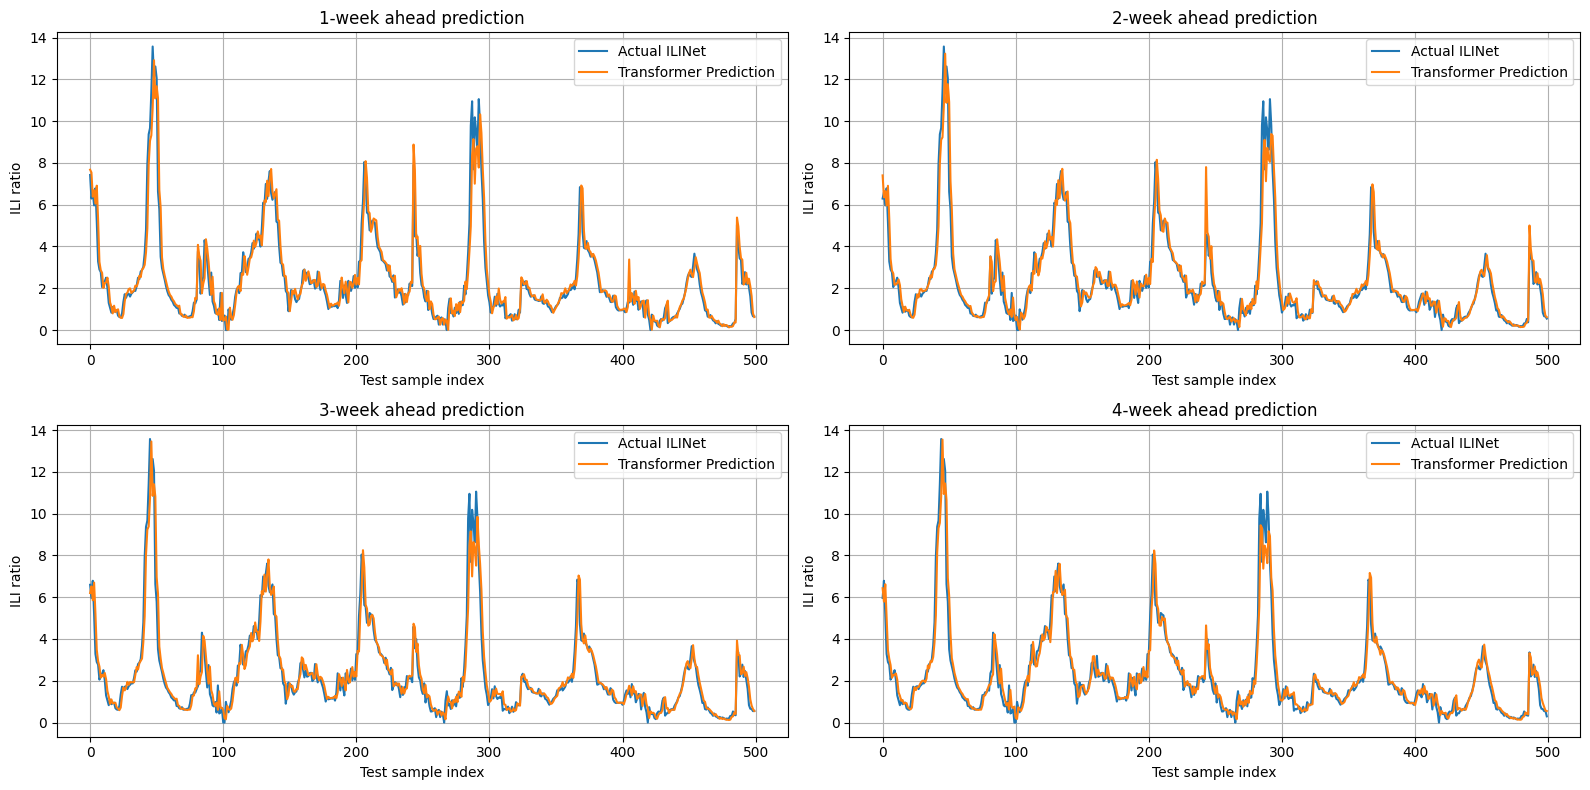

In [7]:
y_true, y_pred = collect_predictions(best_origin_model, test_loader, pipeline.device)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for h in range(4):
    ax = axes[h]

    actual = y_true[:500, h, 0]
    pred = y_pred[:500, h, 0]

    ax.plot(actual, label="Actual ILINet")
    ax.plot(pred, label="Transformer Prediction")

    ax.set_title(f"{h+1}-week ahead prediction")
    ax.set_xlabel("Test sample index")
    ax.set_ylabel("ILI ratio")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

## Evaluation

In [94]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr


# ============================================================
# 1. Safe Pearson
# ============================================================

def safe_pearson(y_true, y_pred):
    """
    Pearson correlation with safe fallback.
    If either array is almost constant, Pearson is undefined.
    """
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    if len(y_true) < 2:
        return np.nan

    if np.std(y_true) < 1e-8 or np.std(y_pred) < 1e-8:
        return np.nan

    return pearsonr(y_true, y_pred)[0]


# ============================================================
# 2. Build per-state test windows
# ============================================================

def get_state_test_windows(
    dataset,
    history=10,
    future=4,
    test_size=0.2,
    val_size=0.1
):
    """
    Build test windows for each state using the same split logic
    as your dataset.build_split_windows().
    """
    df = dataset.clean_dataframe()

    state_windows = {}

    for state, g in df.groupby("REGION"):
        g = g.sort_values(["YEAR", "WEEK"])

        series = g["%UNWEIGHTED ILI"].values.astype(np.float32)

        if len(series) < history + future:
            continue

        _, _, _, _, x_test, y_test = dataset.build_split_windows(
            series=series,
            history=history,
            future=future,
            test_size=test_size,
            val_size=val_size,
        )

        if len(x_test) > 0:
            state_windows[state] = (x_test, y_test)

    return state_windows


# ============================================================
# 3. Transformer per-state prediction
# ============================================================

@torch.no_grad()
def transformer_forecast_state(model, x_windows, y_windows, device):
    """
    Transformer prediction for one state's test windows.

    x_windows: [N, history]
    y_windows: [N, future]

    return:
        pred: [N, future]
    """
    model.eval()

    src = torch.tensor(
        x_windows,
        dtype=torch.float32
    ).unsqueeze(-1).to(device)   # [N, history, 1]

    y = torch.tensor(
        y_windows,
        dtype=torch.float32
    ).unsqueeze(-1).to(device)   # [N, future, 1]

    # Same teacher-forcing evaluation logic as your Transformer pipeline
    tgt_start = src[:, -1:, 0:1]              # [N, 1, 1]
    tgt = torch.cat([tgt_start, y[:, :-1, :]], dim=1)

    pred = model(src, tgt)                    # [N, future, 1]

    return pred.cpu().numpy().squeeze(-1)     # [N, future]


# ============================================================
# 4. LSTM per-state prediction
# ============================================================

@torch.no_grad()
def lstm_forecast_state(model, x_windows, device):
    """
    LSTM prediction for one state's test windows.

    x_windows: [N, history]

    return:
        pred: [N, future]
    """
    model.eval()

    src = torch.tensor(
        x_windows,
        dtype=torch.float32
    ).unsqueeze(-1).to(device)   # [N, history, 1]

    pred = model(src)            # [N, future, 1]

    return pred.cpu().numpy().squeeze(-1)     # [N, future]


# ============================================================
# 5. Compute Transformer vs LSTM per-state metrics
# ============================================================

def evaluate_transformer_lstm_by_state(
    dataset,
    transformer_model,
    lstm_model,
    transformer_device,
    lstm_device,
    history=10,
    future=4,
    test_size=0.2,
    val_size=0.1,
    max_test_windows_per_state=None
):
    """
    Evaluate Transformer and LSTM on the same per-state test windows.
    """

    state_windows = get_state_test_windows(
        dataset=dataset,
        history=history,
        future=future,
        test_size=test_size,
        val_size=val_size
    )

    print(f"Number of states/regions evaluated: {len(state_windows)}")

    rows = []

    for state, (x_test_state, y_test_state) in state_windows.items():

        if max_test_windows_per_state is not None:
            x_eval = x_test_state[:max_test_windows_per_state]
            y_eval = y_test_state[:max_test_windows_per_state]
        else:
            x_eval = x_test_state
            y_eval = y_test_state

        # Transformer prediction
        transformer_pred = transformer_forecast_state(
            model=transformer_model,
            x_windows=x_eval,
            y_windows=y_eval,
            device=transformer_device
        )

        # LSTM prediction
        lstm_pred = lstm_forecast_state(
            model=lstm_model,
            x_windows=x_eval,
            device=lstm_device
        )

        # Flatten all 4 horizons together
        y_flat = y_eval.reshape(-1)
        transformer_flat = transformer_pred.reshape(-1)
        lstm_flat = lstm_pred.reshape(-1)

        rows.append({
            "state": state,

            "transformer_rmse": np.sqrt(mean_squared_error(y_flat, transformer_flat)),
            "transformer_pearson": safe_pearson(y_flat, transformer_flat),

            "lstm_rmse": np.sqrt(mean_squared_error(y_flat, lstm_flat)),
            "lstm_pearson": safe_pearson(y_flat, lstm_flat),
        })

    result_df = pd.DataFrame(rows)

    return result_df



transformer_lstm_df = evaluate_transformer_lstm_by_state(
    dataset=dataset,
    transformer_model=best_origin_model,      # 你的 original transformer model
    lstm_model=best_lstm_model,               # 你的 trained LSTM model
    transformer_device=pipeline.device,       # transformer pipeline device
    lstm_device=lstm_pipeline.device,         # LSTM pipeline device
    history=HISTORY,
    future=FUTURE,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    max_test_windows_per_state=MAX_TEST_WINDOWS_PER_STATE
)

transformer_lstm_df.head()

Number of states/regions evaluated: 54


D:\Softwares\minconda3\envs\llm\Lib\site-packages\torch\nn\modules\rnn.py:1162: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
D:\Softwares\minconda3\envs\llm\Lib\site-packages\torch\nn\modules\rnn.py:1162: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(
D:\Softwares\minconda3\envs\llm\Lib\site-packages\torch\nn\modules\rnn.py:1162: UserWarning: RNN module weights are not part o

,state,transformer_rmse,transformer_pearson,lstm_rmse,lstm_pearson
0,Alabama,0.911562,0.956458,1.695048,0.842257
1,Alaska,0.633262,0.942776,0.967959,0.891865
2,Arizona,0.523190,0.934625,0.844600,0.833016
3,Arkansas,0.996985,0.935437,1.778767,0.775667
4,California,0.417742,0.940488,0.746461,0.812698


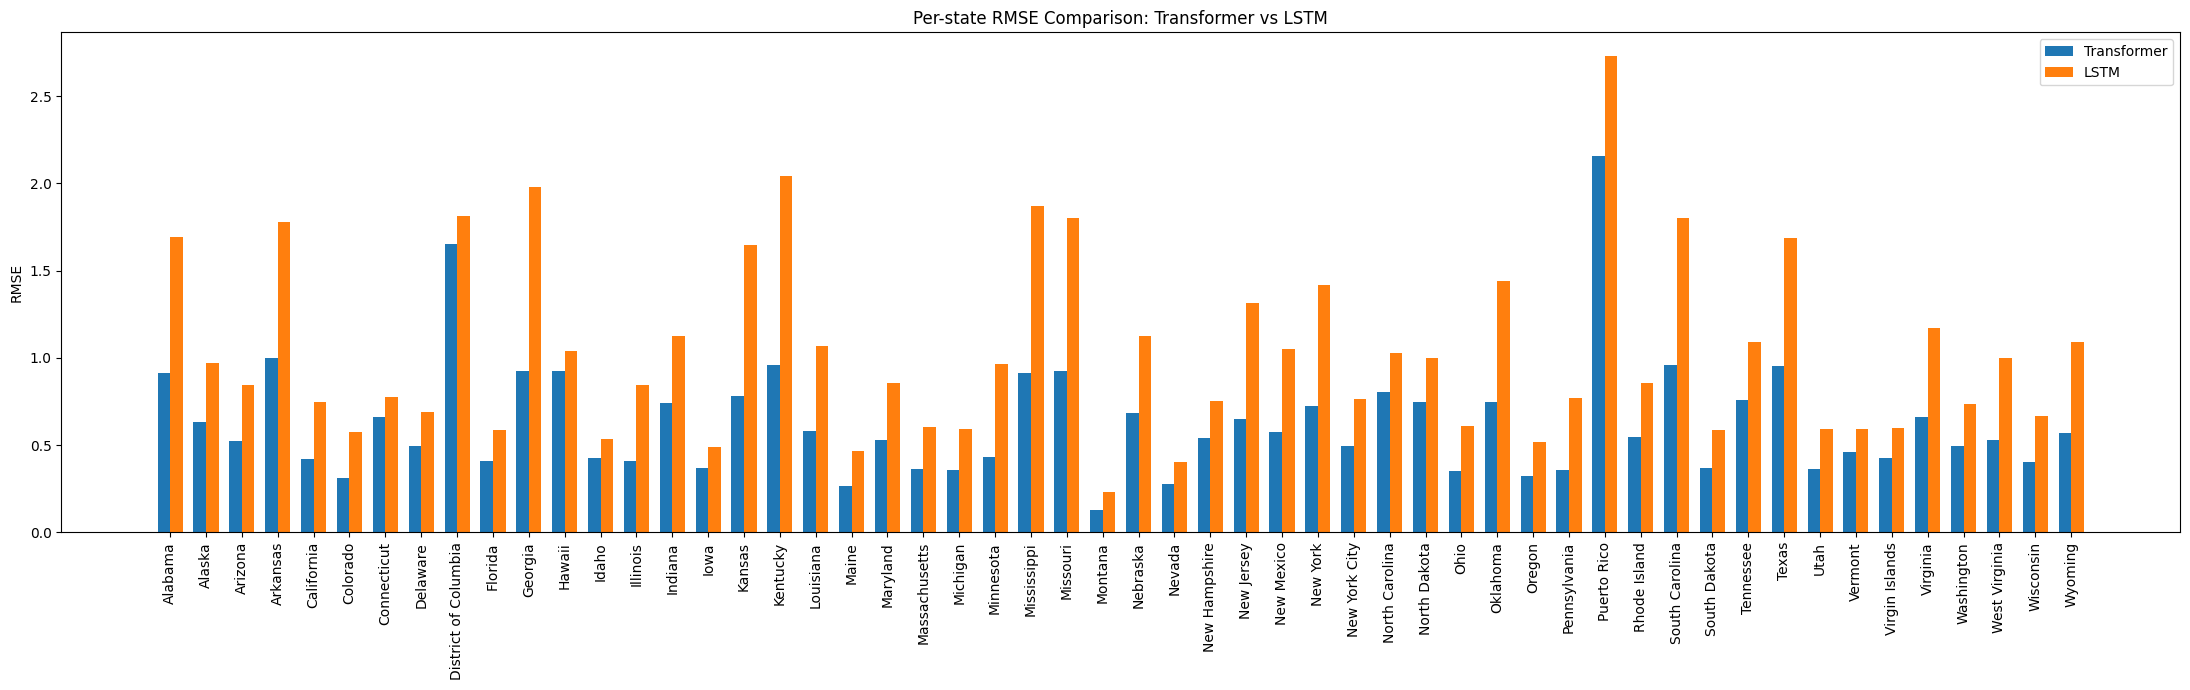

In [46]:
plot_df = transformer_lstm_df.sort_values("state").reset_index(drop=True)

states = plot_df["state"]
x = np.arange(len(states))
width = 0.35

plt.figure(figsize=(22, 7))

plt.bar(
    x - width / 2,
    plot_df["transformer_rmse"],
    width=width,
    label="Transformer"
)

plt.bar(
    x + width / 2,
    plot_df["lstm_rmse"],
    width=width,
    label="LSTM"
)

plt.xticks(x, states, rotation=90)
plt.ylabel("RMSE")
plt.title("Per-state RMSE Comparison: Transformer vs LSTM")
plt.legend()
plt.tight_layout()
plt.show()

In [92]:
@torch.no_grad()
def collect_four_model_predictions_on_test_loader(
    test_loader,
    transformer_model,
    lstm_model,
    transformer_device,
    lstm_device,
    future=4,
    arima_order=(1, 0, 0),
    max_points=500
):
    transformer_model.eval()
    lstm_model.eval()

    all_targets = []
    all_transformer_preds = []
    all_lstm_preds = []
    all_persistence_preds = []
    all_arima_preds = []

    for src, y in test_loader:
        # -----------------------------
        # original shapes:
        # src: [B, history, 1]
        # y:   [B, future, 1]
        # -----------------------------

        # ====================================================
        # Ground truth
        # ====================================================
        y_np = y.cpu().numpy()  # [B, future, 1]

        # ====================================================
        # Transformer prediction
        # ====================================================
        src_tf = src.to(transformer_device)
        y_tf = y.to(transformer_device)

        # same teacher-forcing logic as your transformer evaluation
        tgt_start = src_tf[:, -1:, 0:1]
        tgt = torch.cat([tgt_start, y_tf[:, :-1, :]], dim=1)

        transformer_pred = transformer_model(src_tf, tgt)
        transformer_pred_np = transformer_pred.cpu().numpy()  # [B, future, 1]

        # ====================================================
        # LSTM prediction
        # ====================================================
        src_lstm = src.to(lstm_device)

        lstm_pred = lstm_model(src_lstm)
        lstm_pred_np = lstm_pred.cpu().numpy()  # [B, future, 1]

        # ====================================================
        # Persistence prediction
        # ====================================================
        last_value = src[:, -1:, :]  # [B, 1, 1]
        persistence_pred = last_value.repeat(1, y.shape[1], 1)
        persistence_pred_np = persistence_pred.cpu().numpy()  # [B, future, 1]

        # ====================================================
        # ARIMA prediction
        # ====================================================
        src_np = src.cpu().numpy().squeeze(-1)  # [B, history]

        arima_batch_preds = []

        for i in range(src_np.shape[0]):
            history_values = src_np[i]

            arima_pred = arima_forecast_window(
                history_values=history_values,
                future=future,
                order=arima_order
            )

            arima_batch_preds.append(arima_pred)

        arima_pred_np = np.array(arima_batch_preds)[:, :, None]  # [B, future, 1]

        # ====================================================
        # Store
        # ====================================================
        all_targets.append(y_np)
        all_transformer_preds.append(transformer_pred_np)
        all_lstm_preds.append(lstm_pred_np)
        all_persistence_preds.append(persistence_pred_np)
        all_arima_preds.append(arima_pred_np)

        # stop early if enough flattened points collected
        current_points = sum(arr.size for arr in all_targets)

        if max_points is not None and current_points >= max_points:
            break

    # ========================================================
    # Concatenate and flatten
    # ========================================================

    targets = np.concatenate(all_targets, axis=0).reshape(-1)
    transformer_preds = np.concatenate(all_transformer_preds, axis=0).reshape(-1)
    lstm_preds = np.concatenate(all_lstm_preds, axis=0).reshape(-1)
    persistence_preds = np.concatenate(all_persistence_preds, axis=0).reshape(-1)
    arima_preds = np.concatenate(all_arima_preds, axis=0).reshape(-1)

    # only keep first max_points
    targets = targets[:max_points]
    transformer_preds = transformer_preds[:max_points]
    lstm_preds = lstm_preds[:max_points]
    persistence_preds = persistence_preds[:max_points]
    arima_preds = arima_preds[:max_points]

    return {
        "ground_truth": targets,
        "transformer": transformer_preds,
        "lstm": lstm_preds,
        "persistence": persistence_preds,
        "arima": arima_preds
    }

In [135]:
plot_preds = collect_four_model_predictions_on_test_loader(
    test_loader=test_loader,
    transformer_model=best_origin_model,
    lstm_model=best_lstm_model,
    transformer_device=pipeline.device,
    lstm_device=lstm_pipeline.device,
    future=FUTURE,
    arima_order=ARIMA_ORDER,
    max_points=200
)

D:\Softwares\minconda3\envs\llm\Lib\site-packages\torch\nn\modules\rnn.py:1162: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.lstm(


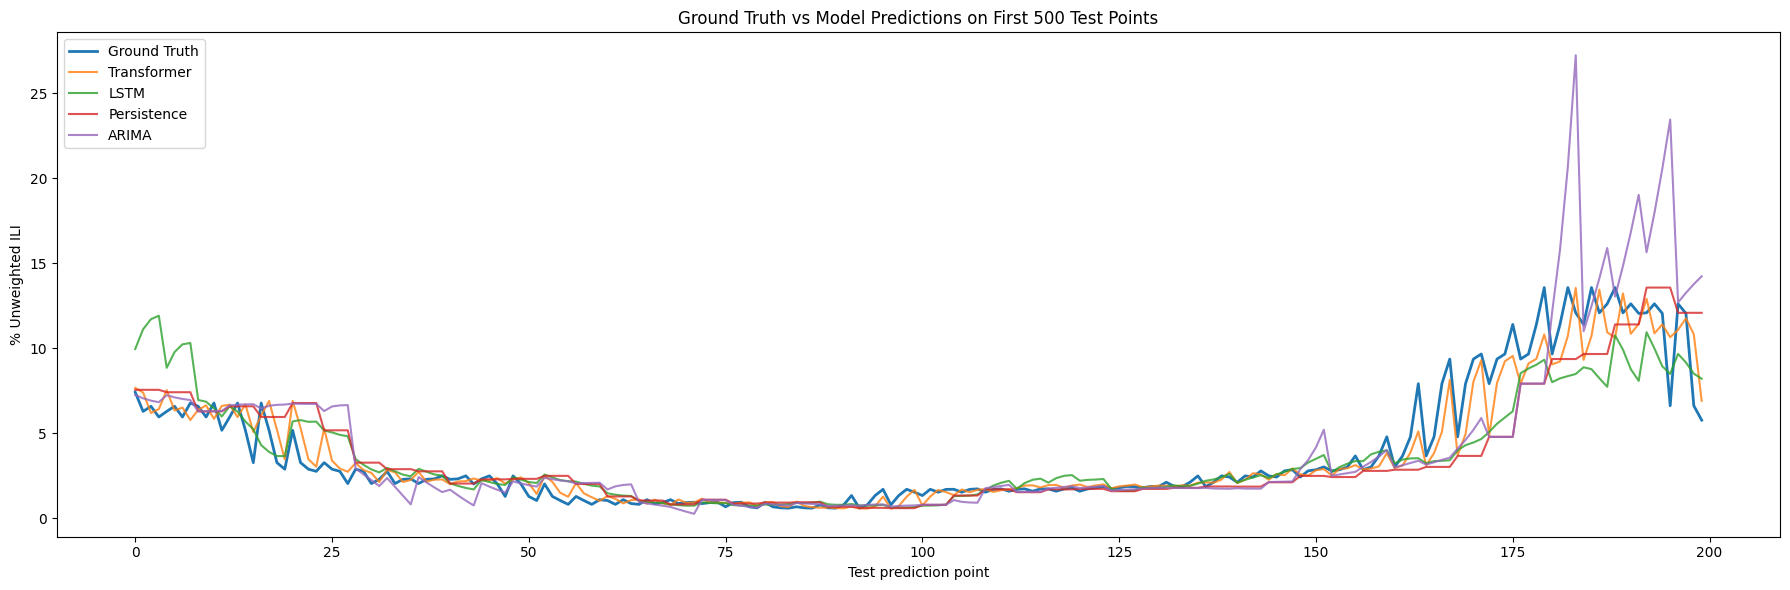

In [136]:
plt.figure(figsize=(18, 6))

x = np.arange(len(plot_preds["ground_truth"]))

plt.plot(
    x,
    plot_preds["ground_truth"],
    label="Ground Truth",
    linewidth=2
)

plt.plot(
    x,
    plot_preds["transformer"],
    label="Transformer",
    alpha=0.8
)

plt.plot(
    x,
    plot_preds["lstm"],
    label="LSTM",
    alpha=0.8
)

plt.plot(
    x,
    plot_preds["persistence"],
    label="Persistence",
    alpha=0.8
)

plt.plot(
    x,
    plot_preds["arima"],
    label="ARIMA",
    alpha=0.8
)

plt.xlabel("Test prediction point")
plt.ylabel("% Unweighted ILI")
plt.title("Ground Truth vs Model Predictions on First 500 Test Points")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plot_preds = collect_four_model_predictions_on_test_loader(
    test_loader=test_loader,
    transformer_model=best_origin_model,
    lstm_model=best_lstm_model,
    transformer_device=pipeline.device,
    lstm_device=lstm_pipeline.device,
    future=FUTURE,
    arima_order=ARIMA_ORDER,
    max_points=None
)

In [132]:
def summarize_four_model_metrics(plot_preds):
    """
    plot_preds should be returned by:
    collect_four_model_predictions_on_test_loader(...)
    
    Required keys:
        ground_truth
        transformer
        lstm
        persistence
        arima
    """

    y_true = plot_preds["ground_truth"].reshape(-1)

    rows = []

    model_keys = {
        "Transformer": "transformer",
        "LSTM": "lstm",
        "Persistence Forecasting": "persistence",
        "ARIMA": "arima",
    }

    for model_name, key in model_keys.items():
        y_pred = plot_preds[key].reshape(-1)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        corr = safe_pearson(y_true, y_pred)

        rows.append({
            "Model": model_name,
            "RMSE": rmse,
            "Pearson Correlation": corr
        })

    metrics_df = pd.DataFrame(rows)

    print("\n" + "=" * 70)
    print("Four-model performance on test_loader")
    print("=" * 70)

    for _, row in metrics_df.iterrows():
        print(
            f"{row['Model']:<25} "
            f"RMSE = {row['RMSE']:.4f} | "
            f"Pearson = {row['Pearson Correlation']:.4f}"
        )

    print("=" * 70)

    return metrics_df

In [133]:
metrics_df = summarize_four_model_metrics(plot_preds)

metrics_df


Four-model performance on test_loader
Transformer               RMSE = 0.6917 | Pearson = 0.9494
LSTM                      RMSE = 1.1397 | Pearson = 0.8571
Persistence Forecasting   RMSE = 1.2176 | Pearson = 0.8510
ARIMA                     RMSE = 1.6990 | Pearson = 0.8048


,Model,RMSE,Pearson Correlation
0,Transformer,0.691694,0.949401
1,LSTM,1.139676,0.857079
2,Persistence Forecasting,1.217555,0.850957
3,ARIMA,1.698952,0.804835


# Improvement - Deep Transformer Models for Time Series Forecasting: The Influenza Prevalence Case

## Weighted Loss Function

In [54]:
y_true_val, y_pred_val = collect_predictions(best_origin_model, val_loader, pipeline.device)

horizon_rmse = compute_horizon_rmse(y_true_val, y_pred_val)

weights= horizon_rmse / horizon_rmse.sum()

In [55]:
class HorizonWeightedMSELoss(torch.nn.Module):
    def __init__(self, weights):
        super().__init__()

        weights = torch.tensor(weights, dtype=torch.float32)

        self.register_buffer("weights", weights)

    def forward(self, pred, target):
        squared_error = (pred - target) ** 2     # [B, H, 1]
        loss_per_horizon = squared_error.mean(dim=(0, 2))  # [H]

        loss = (loss_per_horizon * self.weights).sum()
        return loss

In [56]:
weighted_trx_model = DeepTransformer()

weighted_pipeline = PipeLine(
    model=weighted_trx_model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_func=HorizonWeightedMSELoss(weights)
)


best_weighted_model, weighted_train_losses, weighted_val_losses = weighted_pipeline.train_model(50)

weighted_pipeline.evaluate_metrics(best_weighted_model, test_loader)

Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU
Epoch   1/50 | Train Loss: 2.2053 | Val Loss: 0.5612
Epoch  10/50 | Train Loss: 0.4437 | Val Loss: 0.3377
Epoch  20/50 | Train Loss: 0.4290 | Val Loss: 0.3584
Epoch  30/50 | Train Loss: 0.4105 | Val Loss: 0.3193
Epoch  40/50 | Train Loss: 0.3962 | Val Loss: 0.3568
Epoch  50/50 | Train Loss: 0.3847 | Val Loss: 0.3419
RMSE: 0.7062280001631859
Pearson: 0.9472076


(np.float64(0.7062280001631859), np.float32(0.9472076))

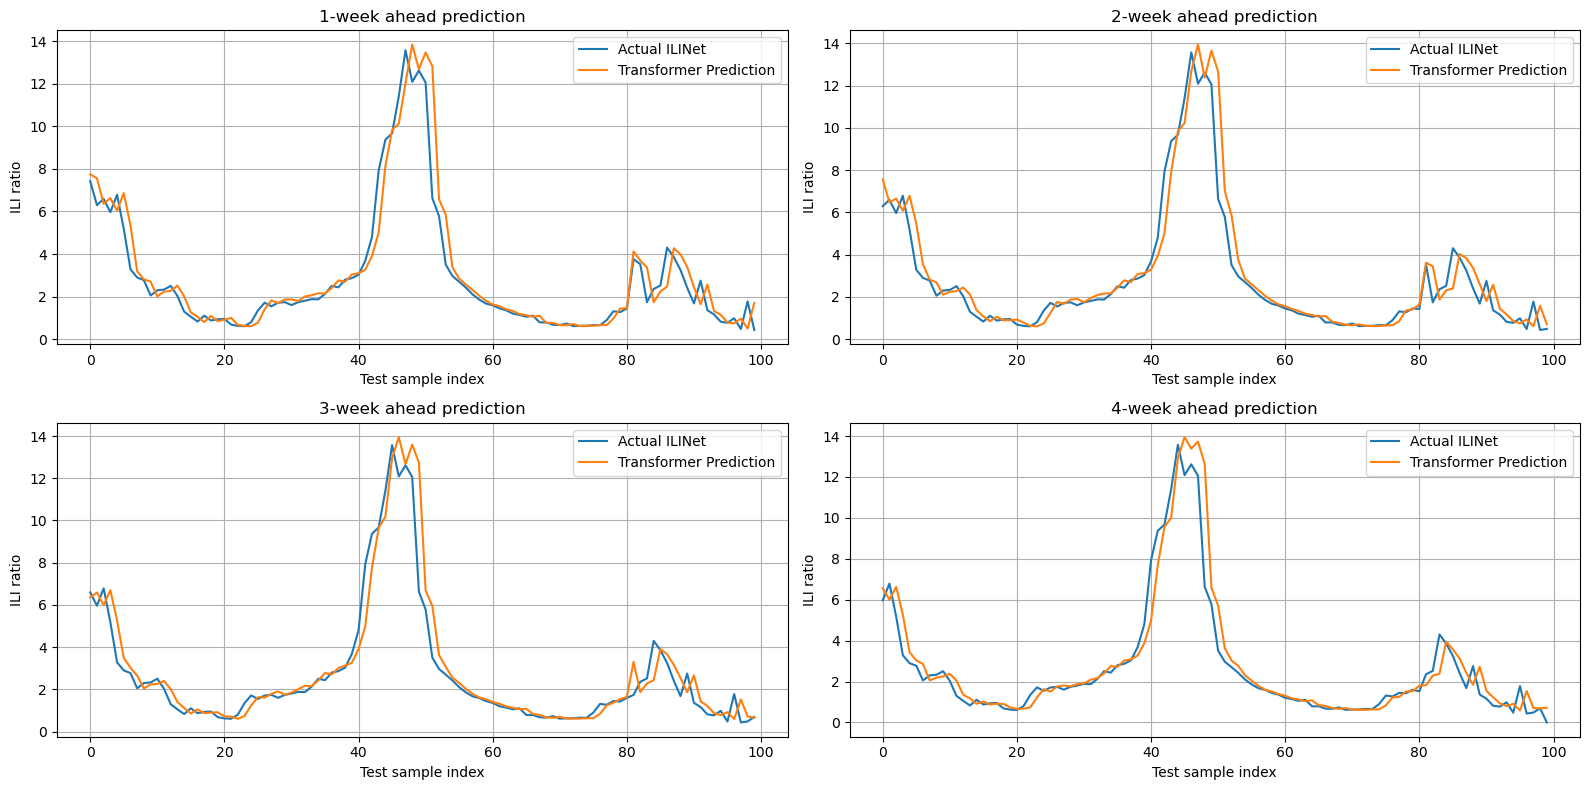

In [32]:
y_true, y_pred = collect_predictions(best_weighted_model, test_loader, pipeline.device)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for h in range(4):
    ax = axes[h]

    actual = y_true[:100, h, 0]
    pred = y_pred[:100, h, 0]

    ax.plot(actual, label="Actual ILINet")
    ax.plot(pred, label="Transformer Prediction")

    ax.set_title(f"{h+1}-week ahead prediction")
    ax.set_xlabel("Test sample index")
    ax.set_ylabel("ILI ratio")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

## Multivariate

### Load dataset

In [137]:
from dataset import MultivariateDataset

In [69]:
multivariate_dt = MultivariateDataset(
    state_ilinet_path="./data/state/ILINet.csv",
    national_ilinet_path="./data/national/ILINet.csv",
    lab_path="./data/state/ICL_NREVSS_Clinical_Labs.csv"
)


multiv_train_loader, multiv_val_loader, multiv_test_loader = multivariate_dt.get_train_val_test_loader()

Feature columns: ['%UNWEIGHTED ILI', 'national_ili', 'PERCENT POSITIVE']
Target column: %UNWEIGHTED ILI
Train samples: 4244
Validation samples: 499
Test samples: 1209
x batch shape: torch.Size([64, 10, 3])
y batch shape: torch.Size([64, 4, 1])


### Train Model

In [70]:
multiv_trx_model = DeepTransformer(
    input_dim=3
)

pipeline = PipeLine(model=multiv_trx_model, train_loader=multiv_train_loader, val_loader=multiv_val_loader)

# best_multiv_trx_model, train_losses, val_losses = pipeline.train_model(100)

multiv_rmse, multiv_corr = pipeline.evaluate_metrics(best_multiv_trx_model, multiv_test_loader)

Device: cuda
GPU: NVIDIA GeForce RTX 2080 Ti
RMSE: 0.56173664
Pearson: 0.9506319069338167


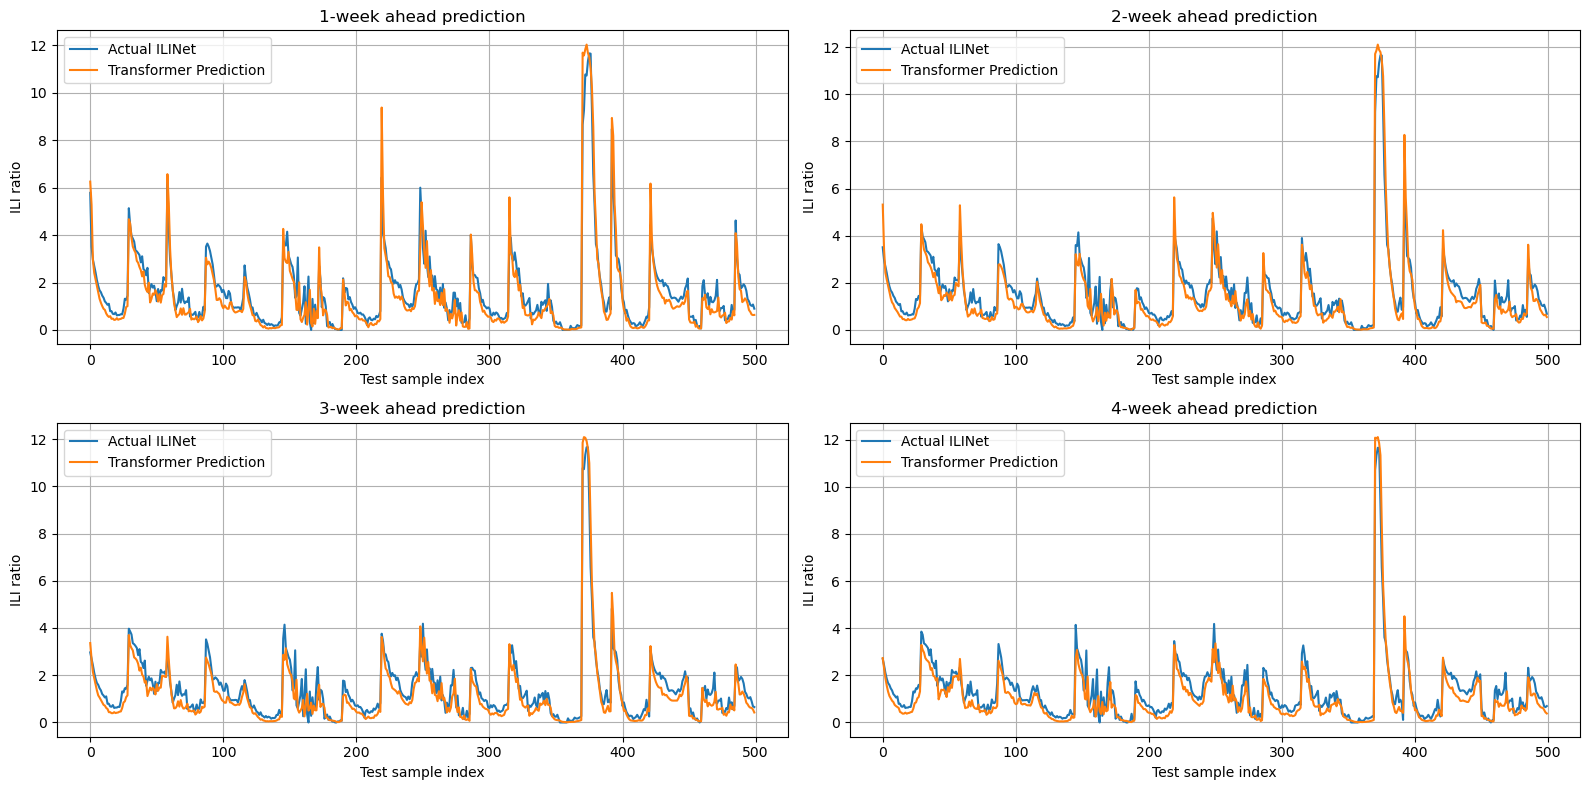

In [61]:
y_true, y_pred = collect_predictions(best_multiv_trx_model, test_loader, pipeline.device)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

for h in range(4):
    ax = axes[h]

    actual = y_true[:500, h, 0]
    pred = y_pred[:500, h, 0]

    ax.plot(actual, label="Actual ILINet")
    ax.plot(pred, label="Transformer Prediction")

    ax.set_title(f"{h+1}-week ahead prediction")
    ax.set_xlabel("Test sample index")
    ax.set_ylabel("ILI ratio")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

## Modern Transformer Architecture

In [66]:
class RotaryEmbedding(nn.Module):
    def __init__(self, head_dim: int, max_seq_len: int = 512, base: int = 10000):
        super().__init__()

        if head_dim % 2 != 0:
            raise ValueError("head_dim must be even for RoPE.")

        inv_freq = 1.0 / (
            base ** (torch.arange(0, head_dim, 2).float() / head_dim)
        )

        positions = torch.arange(max_seq_len).float()
        freqs = torch.einsum("i,j->ij", positions, inv_freq)

        cos = freqs.cos()
        sin = freqs.sin()

        self.register_buffer("cos", cos, persistent=False)
        self.register_buffer("sin", sin, persistent=False)

    def forward(self, q: torch.Tensor, k: torch.Tensor):
        """
        q, k: [B, H, T, Dh]
        """
        T = q.size(2)

        cos = self.cos[:T].to(q.device)  # [T, Dh/2]
        sin = self.sin[:T].to(q.device)  # [T, Dh/2]

        cos = cos.unsqueeze(0).unsqueeze(0)  # [1, 1, T, Dh/2]
        sin = sin.unsqueeze(0).unsqueeze(0)  # [1, 1, T, Dh/2]

        q_even = q[..., 0::2]
        q_odd = q[..., 1::2]
        k_even = k[..., 0::2]
        k_odd = k[..., 1::2]

        q_rot = torch.stack(
            [q_even * cos - q_odd * sin,
             q_even * sin + q_odd * cos],
            dim=-1
        ).flatten(-2)

        k_rot = torch.stack(
            [k_even * cos - k_odd * sin,
             k_even * sin + k_odd * cos],
            dim=-1
        ).flatten(-2)

        return q_rot, k_rot


class CausalSelfAttentionRoPE(nn.Module):
    def __init__(
        self,
        d_model: int,
        num_heads: int,
        dropout: float = 0.1,
        max_seq_len: int = 512
    ):
        super().__init__()

        if d_model % num_heads != 0:
            raise ValueError("d_model must be divisible by num_heads.")

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        if self.head_dim % 2 != 0:
            raise ValueError("head_dim must be even for RoPE.")

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.rope = RotaryEmbedding(
            head_dim=self.head_dim,
            max_seq_len=max_seq_len
        )

        self.attn_dropout = nn.Dropout(dropout)
        self.out_dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor):
        """
        x: [B, T, D]
        """
        B, T, D = x.shape

        q = self.q_proj(x)  # [B, T, D]
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)  # [B, H, T, Dh]
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        q, k = self.rope(q, k)

        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim ** 0.5)
        # [B, H, T, T]

        causal_mask = torch.triu(
            torch.ones(T, T, device=x.device, dtype=torch.bool),
            diagonal=1
        )
        attn_scores = attn_scores.masked_fill(causal_mask, float("-inf"))

        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)

        out = torch.matmul(attn_weights, v)  # [B, H, T, Dh]
        out = out.transpose(1, 2).contiguous().view(B, T, D)  # [B, T, D]

        out = self.out_proj(out)
        out = self.out_dropout(out)

        return out


class FeedForward(nn.Module):
    def __init__(self, d_model: int, ff_dim: int, dropout: float = 0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x: torch.Tensor):
        return self.net(x)


class DecoderOnlyBlock(nn.Module):
    def __init__(
        self,
        d_model: int,
        num_heads: int,
        ff_dim: int,
        dropout: float = 0.1,
        max_seq_len: int = 512
    ):
        super().__init__()

        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttentionRoPE(
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout,
            max_seq_len=max_seq_len
        )

        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(
            d_model=d_model,
            ff_dim=ff_dim,
            dropout=dropout
        )

    def forward(self, x: torch.Tensor):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


class ModernTransformer(nn.Module):
    def __init__(
        self,
        input_dim: int = 3,
        output_dim: int = 1,
        d_model: int = 64,
        num_heads: int = 4,
        ff_dim: int = 256,
        num_layers: int = 4,
        dropout: float = 0.1,
        max_seq_len: int = 64
    ):
        super().__init__()

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.d_model = d_model

        self.src_proj = nn.Linear(input_dim, d_model)
        self.tgt_proj = nn.Linear(output_dim, d_model)

        self.src_type_embedding = nn.Parameter(torch.zeros(1, 1, d_model))
        self.tgt_type_embedding = nn.Parameter(torch.zeros(1, 1, d_model))

        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            DecoderOnlyBlock(
                d_model=d_model,
                num_heads=num_heads,
                ff_dim=ff_dim,
                dropout=dropout,
                max_seq_len=max_seq_len
            )
            for _ in range(num_layers)
        ])

        self.final_ln = nn.LayerNorm(d_model)
        self.output_proj = nn.Linear(d_model, output_dim)

    def forward(self, src: torch.Tensor, tgt: torch.Tensor):
        """
        src: [B, src_len, input_dim]
        tgt: [B, tgt_len, output_dim]

        returns:
            [B, tgt_len, output_dim]
        """
        src_len = src.size(1)
        tgt_len = tgt.size(1)

        src_tokens = self.src_proj(src) + self.src_type_embedding
        tgt_tokens = self.tgt_proj(tgt) + self.tgt_type_embedding

        x = torch.cat([src_tokens, tgt_tokens], dim=1)  # [B, src_len + tgt_len, D]
        x = self.dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.final_ln(x)

        tgt_hidden = x[:, src_len:src_len + tgt_len, :]
        out = self.output_proj(tgt_hidden)

        return out

In [67]:
modern_transformer = ModernTransformer(input_dim=1)

pipeline = PipeLine(model=modern_transformer, train_loader=train_loader, val_loader=val_loader)

best_modern_model, train_losses, val_losses = pipeline.train_model(50)

rmse, corr = pipeline.evaluate_metrics(best_modern_model, test_loader)

Device: cuda
GPU: NVIDIA GeForce RTX 2080 Ti
Epoch   1/50 | Train Loss: 2.0544 | Val Loss: 0.7025
Epoch  10/50 | Train Loss: 0.3905 | Val Loss: 0.3512
Epoch  20/50 | Train Loss: 0.3758 | Val Loss: 0.3572
Epoch  30/50 | Train Loss: 0.3634 | Val Loss: 0.3680
Epoch  40/50 | Train Loss: 0.3473 | Val Loss: 0.3511
Epoch  50/50 | Train Loss: 0.3384 | Val Loss: 0.3785
RMSE: 0.6872087
Pearson: 0.9505051909689255


# Evaluation Between Different Model

In [72]:
from torch.utils.data import TensorDataset, DataLoader

def make_univariate_loader_from_multivariate(multiv_loader, batch_size=64, shuffle=False):
    dataset = multiv_loader.dataset

    x_multi, y = dataset.tensors

    x_uni = x_multi[:, :, 0:1]

    uni_dataset = TensorDataset(x_uni, y)

    uni_loader = DataLoader(
        uni_dataset,
        batch_size=batch_size,
        shuffle=shuffle
    )

    return uni_loader

In [73]:
univ_train_loader = make_univariate_loader_from_multivariate(
    multiv_train_loader,
    batch_size=64,
    shuffle=True
)

univ_val_loader = make_univariate_loader_from_multivariate(
    multiv_val_loader,
    batch_size=64,
    shuffle=False
)

univ_test_loader = make_univariate_loader_from_multivariate(
    multiv_test_loader,
    batch_size=64,
    shuffle=False
)

In [79]:
rmse, corr = pipeline.evaluate_metrics(best_origin_model, univ_test_loader)

RMSE: 0.60742
Pearson: 0.9381809214199943


In [74]:
rmse, corr = pipeline.evaluate_metrics(best_modern_model, univ_test_loader)

RMSE: 0.5935043
Pearson: 0.9400731905228575


In [75]:
rmse, corr = pipeline.evaluate_metrics(weighted_trx_model, univ_test_loader)

RMSE: 0.57115793
Pearson: 0.9399202721173341
